In [1]:
"""
NB08_Multi_Orbit_Evolution

Purpose
-------
Implement the iterated encounter map from Section 4.7:
  1) Mode A (fixed-plane): iterate e_{k+1} = e_k + de_full using the
     one-orbit full Gauss integral, holding the orbital plane fixed.
  2) Mode B (plane-updated): same eccentricity iteration, but also
     update h_vec each orbit via dh = integral(r x dg) dt, then
     re-project the (p,q) basis into the new plane.
  3) Compare the two modes to quantify importance of A_N / plane effects.
  4) Track cumulative altitude drift and plane tilt over N orbits.

Uses de2d_full (complete first-order, validated at 1% in NB07) as the
primary iterated quantity. Also tracks de2d_net (gated) for comparison.

Dependencies: NB03 artifact (for r_eci, dg_eci), NB05v2 artifact
"""

from __future__ import annotations

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

RUN_TAG = datetime.now(timezone.utc).strftime("NB08_%Y%m%dT%H%M%SZ")
print("RUN_TAG:", RUN_TAG)

RUN_TAG: NB08_20260316T134416Z


In [2]:
# ============================================================
# Cell 1 : Auto-discover Artifacts and Config
# ============================================================
ART_DIR = Path("./artifacts")

nb03_files = sorted(ART_DIR.glob("dg_samples_NB03_*_L*.npz"))
nb05_files = sorted(ART_DIR.glob("deltae_NB05_*.npz"))

if not nb03_files:
    raise FileNotFoundError("No NB03 artifact.")
if not nb05_files:
    raise FileNotFoundError("No NB05 artifact.")

NB03_NPZ = nb03_files[-1]
NB05_NPZ = nb05_files[-1]

OUT_NPZ = ART_DIR / f"multi_orbit_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"multi_orbit_{RUN_TAG}.json"

N_ORBITS = 50

print(f"NB03 : {NB03_NPZ.name}")
print(f"NB05 : {NB05_NPZ.name}")
print(f"Output: {OUT_NPZ.name}")
print(f"N_ORBITS = {N_ORBITS}")

NB03 : dg_samples_NB03_20260316T033826Z_L200.npz
NB05 : deltae_NB05_20260316T125355Z.npz
Output: multi_orbit_NB08_20260316T134416Z.npz
N_ORBITS = 50


In [3]:
# ============================================================
# Cell 2 : Load Data
# ============================================================
dg  = np.load(NB03_NPZ, allow_pickle=False)
nb5 = np.load(NB05_NPZ, allow_pickle=False)

t       = dg["t"].astype(float)         # (M,)
r_eci   = dg["r_eci"].astype(float)     # (M, 3)
v_eci   = dg["v_eci"].astype(float)     # (M, 3)

# Disturbing acceleration in inertial (for dh computation)
dg_eci  = dg["dg_eci"].astype(float)    # (M, 3)

# NB05 results
de2d_full_1 = nb5["de2d_full"].astype(float).ravel()  # (2,) full-orbit Δe per rev
de2d_net_1  = nb5["de2d_net"].astype(float).ravel()   # (2,) gated Δe per rev
F_amp       = float(nb5["F_amp"])

# Fixed in-plane basis from NB05
p_hat0 = nb5["p_hat"].astype(float).ravel()
q_hat0 = nb5["q_hat"].astype(float).ravel()

M  = t.size
dt = float(np.median(np.diff(t)))

print(f"M = {M}   dt ~ {dt:.4f} s")
print(f"F_amp = {F_amp:.4f} km")
print(f"de2d_full (one orbit) = [{de2d_full_1[0]:+.6e}, {de2d_full_1[1]:+.6e}]  ||={np.linalg.norm(de2d_full_1):.6e}")
print(f"de2d_net  (one orbit) = [{de2d_net_1[0]:+.6e}, {de2d_net_1[1]:+.6e}]  ||={np.linalg.norm(de2d_net_1):.6e}")

M = 4000   dt ~ 1.6952 s
F_amp = 1787.4000 km
de2d_full (one orbit) = [+3.490250e-05, +2.759606e-04]  ||=2.781591e-04
de2d_net  (one orbit) = [+4.944666e-05, +1.296426e-05]  ||=5.111794e-05


In [4]:
# ============================================================
# Cell 3 : Initial Orbital Plane and Basis
# ============================================================
def unit(v, eps=1e-30):
    n = float(np.linalg.norm(v))
    if n < eps: raise ValueError("Zero-norm vector")
    return np.asarray(v, float) / n

def project_to_plane(p, h_hat):
    """Project p into plane normal to h_hat, renormalize."""
    return unit(p - float(np.dot(p, h_hat)) * h_hat)

# Initial angular momentum vector
h_vec0 = np.cross(r_eci[0], v_eci[0])  # km^2/s
h_hat0 = unit(h_vec0)

# Ensure p_hat0 is in-plane
p_hat0 = project_to_plane(p_hat0, h_hat0)
q_hat0 = unit(np.cross(h_hat0, p_hat0))

print(f"h_vec0 = {h_vec0}  ||h|| = {np.linalg.norm(h_vec0):.6f} km^2/s")
print(f"h_hat0 = {h_hat0}")
print(f"p_hat0 = {p_hat0}")
print(f"q_hat0 = {q_hat0}")
print(f"handedness (p x q · h) = {np.dot(np.cross(p_hat0, q_hat0), h_hat0):.6f}")

h_vec0 = [-0.00000000e+00  2.96028121e+03  1.81264946e-13]  ||h|| = 2960.281212 km^2/s
h_hat0 = [-0.000000e+00  1.000000e+00  6.123234e-17]
p_hat0 = [1. 0. 0.]
q_hat0 = [ 0.000000e+00  6.123234e-17 -1.000000e+00]
handedness (p x q · h) = 1.000000


In [5]:
# ============================================================
# Cell 4 : Compute One-Orbit Angular Momentum Increment (for Mode B)
# ============================================================
# Section 4.7:  dh_k = integral(r(nu) x dg(nu)) dt
# This drives orbital-plane reorientation via A_N.
# Use trapezoidal integration over the NB03 time grid.

torque = np.cross(r_eci, dg_eci)  # (M, 3) km^2/s^2 * s = torque

dh_1 = np.array([
    float(np.trapezoid(torque[:, 0], x=t)),
    float(np.trapezoid(torque[:, 1], x=t)),
    float(np.trapezoid(torque[:, 2], x=t)),
])  # km^2/s  (angular momentum increment per orbit)

dh_1_norm = float(np.linalg.norm(dh_1))
h_norm0   = float(np.linalg.norm(h_vec0))

print(f"dh_1 [km^2/s] = {dh_1}")
print(f"||dh_1||      = {dh_1_norm:.6e}")
print(f"||dh_1||/||h|| = {dh_1_norm/h_norm0:.6e}  (fractional plane change per orbit)")
print(f"Plane tilt per orbit ~ {np.degrees(dh_1_norm/h_norm0):.4f} deg")

dh_1 [km^2/s] = [-0.97175926  0.00246475 -0.23177383]
||dh_1||      = 9.990201e-01
||dh_1||/||h|| = 3.374747e-04  (fractional plane change per orbit)
Plane tilt per orbit ~ 0.0193 deg


In [6]:
# ============================================================
# Cell 5 : Mode A — Fixed-Plane Iteration
# ============================================================
# e_{k+1} = e_k + de2d_full_1  (same increment every orbit)
# This is equivalent to e_k = k * de2d_full_1 for the full-orbit integral.

N = N_ORBITS

# Accumulate in 2D (p,q) space
de_cum_A_full = np.zeros((N, 2), dtype=float)   # cumulative Δe from full-orbit integral
de_cum_A_net  = np.zeros((N, 2), dtype=float)   # cumulative Δe from gated encounters
dhmax_A_full  = np.zeros(N, dtype=float)
dhmax_A_net   = np.zeros(N, dtype=float)

for k in range(N):
    de_cum_A_full[k] = (k + 1) * de2d_full_1
    de_cum_A_net[k]  = (k + 1) * de2d_net_1
    dhmax_A_full[k]  = F_amp * float(np.linalg.norm(de_cum_A_full[k]))
    dhmax_A_net[k]   = F_amp * float(np.linalg.norm(de_cum_A_net[k]))

print(f"Mode A (fixed-plane):")
print(f"  Full-orbit: dhmax after 1 orbit = {dhmax_A_full[0]*1000:.2f} m,  after {N} = {dhmax_A_full[-1]*1000:.2f} m")
print(f"  Gated net:  dhmax after 1 orbit = {dhmax_A_net[0]*1000:.2f} m,  after {N} = {dhmax_A_net[-1]*1000:.2f} m")

Mode A (fixed-plane):
  Full-orbit: dhmax after 1 orbit = 497.18 m,  after 50 = 24859.08 m
  Gated net:  dhmax after 1 orbit = 91.37 m,  after 50 = 4568.41 m


In [7]:
# ============================================================
# Cell 6 : Mode B — Plane-Updated Iteration
# ============================================================
# Each orbit:
#   1) Apply de2d_full_1 in the CURRENT (p,q) basis -> 3D inertial Δe
#   2) Accumulate e_vec in 3D inertial
#   3) Update h_vec += dh_1 (same dh_1 each orbit — frozen from orbit 1)
#   4) Re-derive h_hat, re-project p_hat/q_hat into new plane
#
# NOTE: This is a first-order approximation. A full implementation
# would re-evaluate the gravity field along the new ground track
# each orbit. Here we use frozen per-orbit increments (de2d_full_1, dh_1)
# but rotate the basis, capturing the geometric effect of plane precession.

h_vec     = h_vec0.copy()
h_hat     = h_hat0.copy()
p_hat     = p_hat0.copy()
q_hat     = q_hat0.copy()
de_eci_accum = np.zeros(3, dtype=float)

# Storage
de_cum_B_full  = np.zeros((N, 2), dtype=float)  # cumulative Δe projected back to initial (p0,q0)
dhmax_B_full   = np.zeros(N, dtype=float)
h_hat_hist     = np.zeros((N + 1, 3), dtype=float)
p_hat_hist     = np.zeros((N + 1, 3), dtype=float)
q_hat_hist     = np.zeros((N + 1, 3), dtype=float)

h_hat_hist[0] = h_hat
p_hat_hist[0] = p_hat
q_hat_hist[0] = q_hat

for k in range(N):
    # Apply one-orbit Δe in current (p,q) basis as 3D inertial vector
    de_inc_eci = de2d_full_1[0] * p_hat + de2d_full_1[1] * q_hat
    de_eci_accum += de_inc_eci

    # Project cumulative 3D Δe back to initial (p0,q0) for comparison with Mode A
    de_cum_B_full[k, 0] = float(np.dot(de_eci_accum, p_hat0))
    de_cum_B_full[k, 1] = float(np.dot(de_eci_accum, q_hat0))
    dhmax_B_full[k] = F_amp * float(np.linalg.norm(de_eci_accum))

    # Update orbital plane
    h_vec = h_vec + dh_1
    h_hat = unit(h_vec)

    # Re-project p_hat into new plane, derive q_hat
    p_hat = project_to_plane(p_hat, h_hat)
    q_hat = unit(np.cross(h_hat, p_hat))

    h_hat_hist[k + 1] = h_hat
    p_hat_hist[k + 1] = p_hat
    q_hat_hist[k + 1] = q_hat

# Total plane tilt after N orbits
total_tilt = np.degrees(np.arccos(np.clip(np.dot(h_hat_hist[0], h_hat_hist[-1]), -1, 1)))

print(f"Mode B (plane-updated):")
print(f"  dhmax after 1 orbit = {dhmax_B_full[0]*1000:.2f} m,  after {N} = {dhmax_B_full[-1]*1000:.2f} m")
print(f"  Total plane tilt after {N} orbits = {total_tilt:.4f} deg")

Mode B (plane-updated):
  dhmax after 1 orbit = 497.18 m,  after 50 = 24859.07 m
  Total plane tilt after 50 orbits = 0.9667 deg


In [8]:
# ============================================================
# Cell 7 : Mode A vs Mode B Comparison
# ============================================================
# The divergence between modes quantifies the importance of A_N
# (out-of-plane dynamics) for long-term altitude prediction.

div_km = np.abs(dhmax_A_full - dhmax_B_full)
div_pct = div_km / np.maximum(dhmax_A_full, 1e-30) * 100

# Per-orbit plane tilt
tilt_per_orbit = np.degrees(np.arccos(
    np.clip(np.sum(h_hat_hist[:-1] * h_hat_hist[1:], axis=1), -1, 1)
))

print(f"{'='*70}")
print(f"  MODE A vs MODE B COMPARISON")
print(f"{'='*70}")
print(f"  {'Orbit':>5s}  {'dhmax_A [m]':>12s}  {'dhmax_B [m]':>12s}  {'Diff [m]':>10s}  {'Diff %':>8s}")
for k in [0, 4, 9, 19, 49]:
    if k < N:
        print(f"  {k+1:5d}  {dhmax_A_full[k]*1000:12.2f}  {dhmax_B_full[k]*1000:12.2f}  {div_km[k]*1000:10.4f}  {div_pct[k]:8.4f}")

print(f"\n  Plane tilt per orbit: min={tilt_per_orbit.min():.5f} deg,  max={tilt_per_orbit.max():.5f} deg")
print(f"  Cumulative tilt after {N} orbits: {total_tilt:.4f} deg")
print(f"\n  Conclusion: {'A_N effects negligible' if div_pct[-1] < 1.0 else 'A_N effects significant'} "
      f"over {N} orbits ({div_pct[-1]:.3f}% divergence).")

  MODE A vs MODE B COMPARISON
  Orbit   dhmax_A [m]   dhmax_B [m]    Diff [m]    Diff %
      1        497.18        497.18      0.0000    0.0000
      5       2485.91       2485.91      0.0000    0.0000
     10       4971.82       4971.82      0.0000    0.0000
     20       9943.63       9943.63      0.0002    0.0000
     50      24859.08      24859.07      0.0034    0.0000

  Plane tilt per orbit: min=0.01933 deg,  max=0.01934 deg
  Cumulative tilt after 50 orbits: 0.9667 deg

  Conclusion: A_N effects negligible over 50 orbits (0.000% divergence).


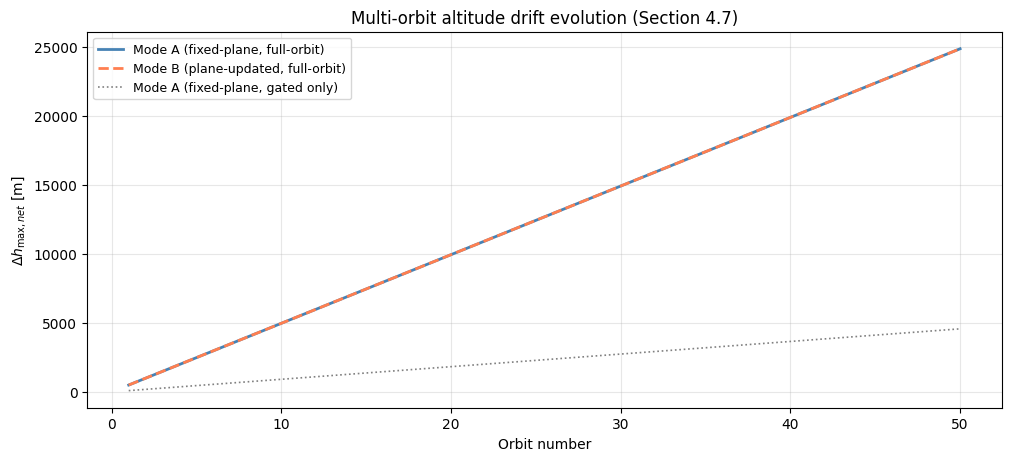

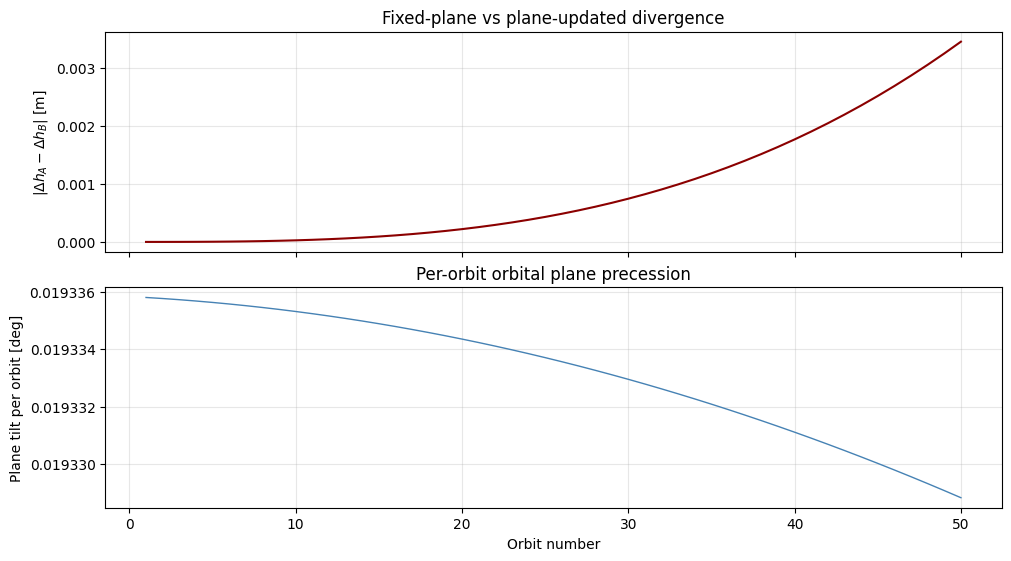

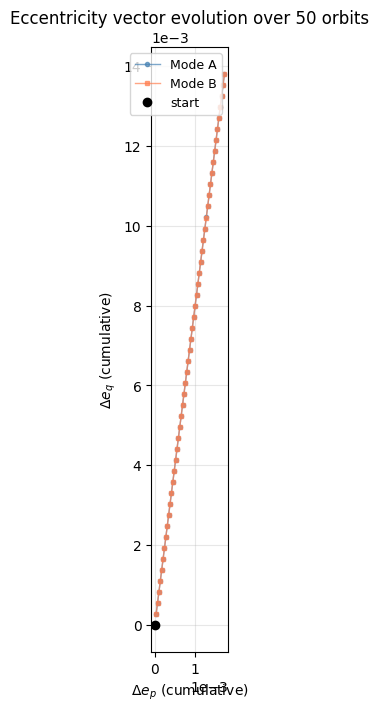

In [9]:
# ============================================================
# Cell 8 : Plots
# ============================================================
orbits = np.arange(1, N + 1)

# --- Plot 1: Cumulative altitude drift (both modes + gated) ---
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.plot(orbits, dhmax_A_full * 1000, lw=2.0, color="steelblue",
        label="Mode A (fixed-plane, full-orbit)")
ax.plot(orbits, dhmax_B_full * 1000, lw=2.0, color="coral", ls="--",
        label="Mode B (plane-updated, full-orbit)")
ax.plot(orbits, dhmax_A_net * 1000, lw=1.2, color="gray", ls=":",
        label="Mode A (fixed-plane, gated only)")
ax.set_xlabel("Orbit number")
ax.set_ylabel(r"$\Delta h_{\max,net}$ [m]")
ax.set_title("Multi-orbit altitude drift evolution (Section 4.7)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.show()

# --- Plot 2: Mode A vs B divergence ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), constrained_layout=True, sharex=True)

ax1.plot(orbits, div_km * 1000, lw=1.5, color="darkred")
ax1.set_ylabel("$|\\Delta h_A - \\Delta h_B|$ [m]")
ax1.set_title("Fixed-plane vs plane-updated divergence")
ax1.grid(True, alpha=0.3)

ax2.plot(orbits, tilt_per_orbit, lw=1.0, color="steelblue")
ax2.set_xlabel("Orbit number")
ax2.set_ylabel("Plane tilt per orbit [deg]")
ax2.set_title("Per-orbit orbital plane precession")
ax2.grid(True, alpha=0.3)
plt.show()

# --- Plot 3: Cumulative Δe trajectory in (p0, q0) plane ---
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.plot(de_cum_A_full[:, 0], de_cum_A_full[:, 1], "o-", ms=3, lw=1.0,
        color="steelblue", label="Mode A", alpha=0.7)
ax.plot(de_cum_B_full[:, 0], de_cum_B_full[:, 1], "s-", ms=3, lw=1.0,
        color="coral", label="Mode B", alpha=0.7)
ax.plot(0, 0, "ko", ms=6, label="start")
ax.set_xlabel(r"$\Delta e_p$ (cumulative)", fontsize=10)
ax.set_ylabel(r"$\Delta e_q$ (cumulative)", fontsize=10)
ax.set_title(f"Eccentricity vector evolution over {N} orbits")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.ticklabel_format(style="scientific", scilimits=(-3, -3))
plt.show()

In [10]:
# ============================================================
# Cell 9 : Save Artifacts
# ============================================================
meta = {
    "run_tag":    RUN_TAG,
    "N_orbits":   N,
    "inputs": {
        "NB03": str(NB03_NPZ),
        "NB05": str(NB05_NPZ),
    },
    "per_orbit_increments": {
        "de2d_full_1": de2d_full_1.tolist(),
        "de2d_net_1":  de2d_net_1.tolist(),
        "dh_1_km2_s":  dh_1.tolist(),
        "dh_1_norm":   dh_1_norm,
        "tilt_per_orbit_deg": float(np.degrees(dh_1_norm / h_norm0)),
    },
    "results": {
        "mode_A_dhmax_final_m": float(dhmax_A_full[-1] * 1000),
        "mode_B_dhmax_final_m": float(dhmax_B_full[-1] * 1000),
        "divergence_pct":       float(div_pct[-1]),
        "total_tilt_deg":       total_tilt,
    },
    "conventions": {
        "de2d_iterated":  "de2d_full (complete first-order, validated at ~1%)",
        "basis":          "p_hat=rhat(t0), q_hat=that(t0) from NB05",
        "dh_computation": "trapezoidal integral of r x dg_eci over NB03 time grid",
    },
}

np.savez(
    OUT_NPZ,
    N_orbits=N,
    F_amp=F_amp,
    # Mode A
    de_cum_A_full=de_cum_A_full,
    de_cum_A_net=de_cum_A_net,
    dhmax_A_full=dhmax_A_full,
    dhmax_A_net=dhmax_A_net,
    # Mode B
    de_cum_B_full=de_cum_B_full,
    dhmax_B_full=dhmax_B_full,
    h_hat_hist=h_hat_hist,
    p_hat_hist=p_hat_hist,
    q_hat_hist=q_hat_hist,
    tilt_per_orbit=tilt_per_orbit,
    # Per-orbit increments
    dh_1=dh_1,
    de2d_full_1=de2d_full_1,
    de2d_net_1=de2d_net_1,
    # Meta
    meta_json=json.dumps(meta),
)

OUT_JSON.write_text(json.dumps({"meta": meta}, indent=2), encoding="utf-8")

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB08 complete ---")

Saved: artifacts\multi_orbit_NB08_20260316T134416Z.npz
Saved: artifacts\multi_orbit_NB08_20260316T134416Z.json

--- NB08 complete ---
